**A. Price Prediction (Regression)**

*   **Objective**: Predict the `Ticket_Price_clipped` based on other transaction and engineered features.


*   **Models Evaluated**: Linear Regression, Random Forest Regressor, and XGBoost Regressor.


*   **Performance**: The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²). A summary table presented the performance metrics for comparison. The R-squared values were relatively low across all models, suggesting that the selected features explain a limited portion of the variance in the clipped ticket price.


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder


In [3]:
# Load the dataset
df = pd.read_csv('synthetic_sports_transactions.csv')
df.head(5)

,Event_ID,League_Code,Team_A_Code,Team_B_Code,Match_Date,Stadium_Code,City_Code,Seat_Category_Code,Ticket_Price,Sale_Date,Days_Before_Match,Quantity,Weather_Code,Day_of_Week_Code,Demand_Level_Code
0,436,7,64,70,2025-05-21,8,8,3,15000,2024-12-22,150,5,2,3,2
1,192,2,17,13,2024-04-19,10,10,4,11059,2024-04-04,15,3,4,5,2
2,485,3,28,30,2025-02-15,10,10,1,11935,2024-10-08,130,4,4,6,2
3,431,8,79,80,2024-12-03,2,2,2,15000,2024-10-20,44,2,2,2,3
4,462,8,74,78,2023-08-05,9,9,1,9060,2023-07-21,15,1,1,6,3


In [4]:
# Univariate summaries for numeric columns
print("Descriptive statistics for numeric columns:")
display(df[['Ticket_Price', 'Days_Before_Match', 'Quantity']].describe())

Descriptive statistics for numeric columns:


,Ticket_Price,Days_Before_Match,Quantity
count,10000.000000,10000.000000,10000.000000
mean,11879.093800,89.913100,5.520700
std,4558.080958,51.958013,2.874543
min,229.000000,1.000000,1.000000
25%,8925.500000,45.000000,3.000000
50%,15000.000000,90.000000,6.000000
75%,15000.000000,135.000000,8.000000
max,15000.000000,180.000000,10.000000


In [5]:
# Value counts for categorical columns
print("\nValue counts for categorical columns:")
categorical_cols = ['League_Code', 'Seat_Category_Code', 'Day_of_Week_Code', 'Demand_Level_Code']
for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    display(df[col].value_counts())


Value counts for categorical columns:

Value counts for League_Code:


League_Code
1     1034
9     1023
8     1017
2     1012
7     1008
6      999
5      983
4      983
10     971
3      970
Name: count, dtype: int64


Value counts for Seat_Category_Code:


Seat_Category_Code
2    2548
1    2498
3    2488
4    2466
Name: count, dtype: int64


Value counts for Day_of_Week_Code:


Day_of_Week_Code
2    1491
6    1451
5    1443
1    1430
4    1409
3    1397
7    1379
Name: count, dtype: int64


Value counts for Demand_Level_Code:


Demand_Level_Code
2    4024
1    3924
3    2052
Name: count, dtype: int64

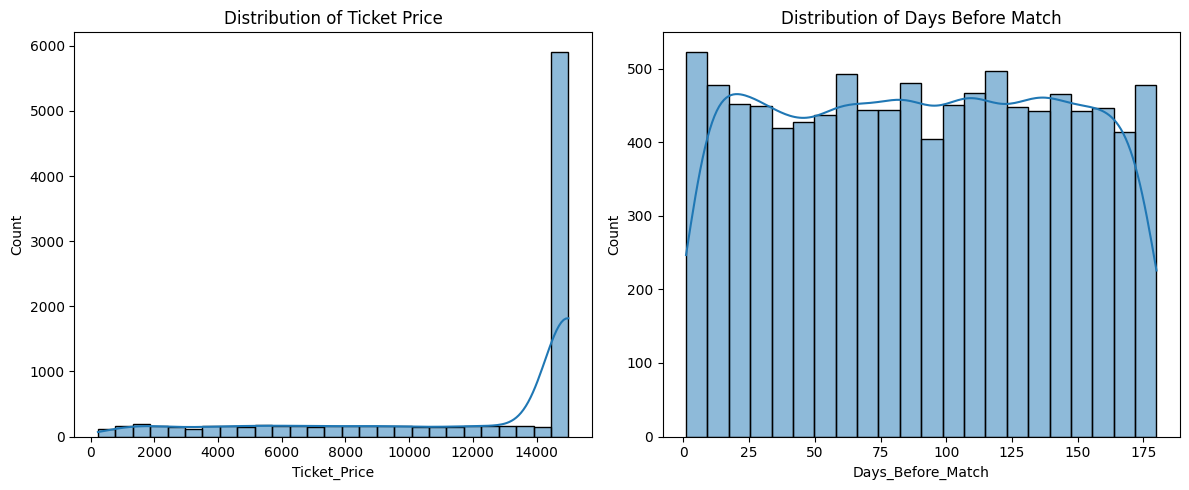

In [6]:
# Histograms of Ticket_Price and Days_Before_Match
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Ticket_Price'], kde=True)
plt.title('Distribution of Ticket Price')

plt.subplot(1, 2, 2)
sns.histplot(df['Days_Before_Match'], kde=True)
plt.title('Distribution of Days Before Match')

plt.tight_layout()
plt.show()

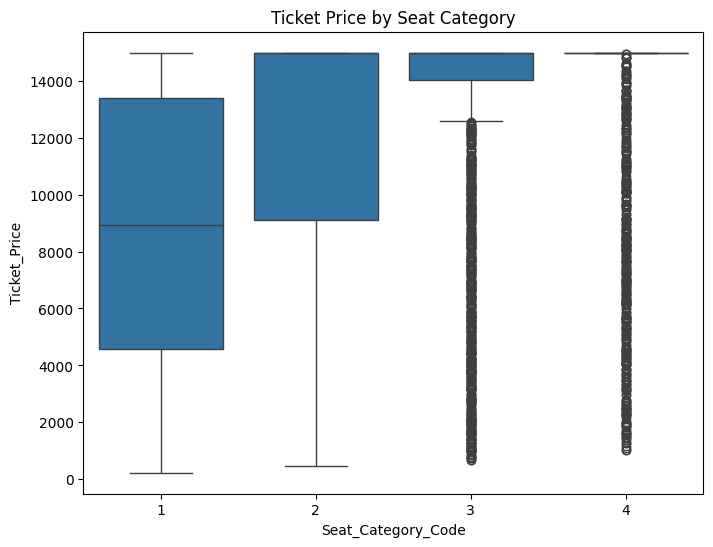

In [7]:
# Boxplots of Ticket_Price by Seat_Category_Code
plt.figure(figsize=(8, 6))
sns.boxplot(x='Seat_Category_Code', y='Ticket_Price', data=df)
plt.title('Ticket Price by Seat Category')
plt.show()

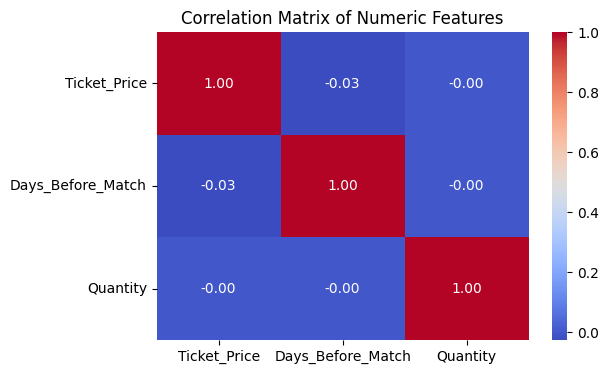

In [8]:
# Correlation matrix between all numeric features
numeric_cols = ['Ticket_Price', 'Days_Before_Match', 'Quantity']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [9]:
# Cross-tabs for League_Code and Demand_Level_Code
print("\nCross-tabulation of League_Code and Demand_Level_Code (normalized by row):")
cross_tab = pd.crosstab(df['League_Code'], df['Demand_Level_Code'], normalize='index')
display(cross_tab)


Cross-tabulation of League_Code and Demand_Level_Code (normalized by row):


Demand_Level_Code,1,2,3
League_Code,,,
1,0.381044,0.386847,0.232108
2,0.385375,0.385375,0.229249
3,0.402062,0.406186,0.191753
4,0.377416,0.397762,0.224822
5,0.404883,0.413021,0.182096
6,0.392392,0.432432,0.175175
7,0.398810,0.415675,0.185516
8,0.401180,0.391347,0.207473
9,0.385142,0.411535,0.203324


In [10]:
# Outlier handling for Ticket_Price (clipping)
lower_bound = df['Ticket_Price'].quantile(0.01)
upper_bound = df['Ticket_Price'].quantile(0.99)
df['Ticket_Price_clipped'] = df['Ticket_Price'].clip(lower=lower_bound, upper=upper_bound)

print(f"Original Ticket_Price range: {df['Ticket_Price'].min()} - {df['Ticket_Price'].max()}")
print(f"Clipped Ticket_Price range: {df['Ticket_Price_clipped'].min()} - {df['Ticket_Price_clipped'].max()}")


Original Ticket_Price range: 229 - 15000
Clipped Ticket_Price range: 723.9300000000001 - 15000.0


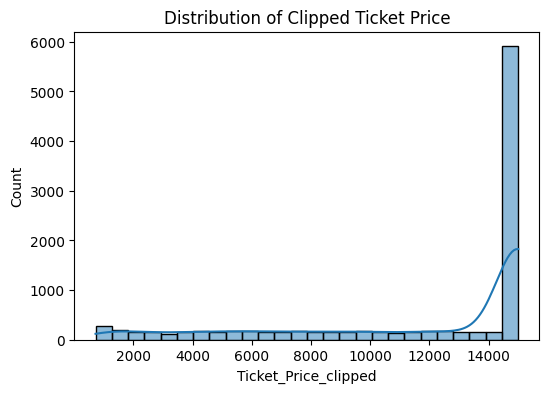

In [11]:
# You can visualize the clipped distribution to see the effect
plt.figure(figsize=(6, 4))
sns.histplot(df['Ticket_Price_clipped'], kde=True)
plt.title('Distribution of Clipped Ticket Price')
plt.show()

In [12]:
# Binning Days_Before_Match
bins = [0, 7, 30, 90, 180]
labels = ['0-7', '8-30', '31-90', '91-180']
df['Days_Before_Match_Binned'] = pd.cut(df['Days_Before_Match'], bins=bins, labels=labels, right=True)
display(df[['Days_Before_Match', 'Days_Before_Match_Binned']].head())

,Days_Before_Match,Days_Before_Match_Binned
0,150,91-180
1,15,8-30
2,130,91-180
3,44,31-90
4,15,8-30


In [13]:
# Create "Weekday vs. Weekend" flag
df['Is_Weekend'] = df['Day_of_Week_Code'].apply(lambda x: 1 if x in [6, 7] else 0)
display(df[['Day_of_Week_Code', 'Is_Weekend']].head())

,Day_of_Week_Code,Is_Weekend
0,3,0
1,5,0
2,6,1
3,2,0
4,6,1


In [14]:
# Interaction terms
df['League_Seat_Interaction'] = df['League_Code'].astype(str) + '_' + df['Seat_Category_Code'].astype(str)
display(df[['League_Code', 'Seat_Category_Code', 'League_Seat_Interaction']].head())


,League_Code,Seat_Category_Code,League_Seat_Interaction
0,7,3,7_3
1,2,4,2_4
2,3,1,3_1
3,8,2,8_2
4,8,1,8_1


In [15]:
# Aggregates per Event_ID
event_aggregates = df.groupby('Event_ID').agg(
    Total_Tickets_Sold=('Quantity', 'sum'),
    Average_Price=('Ticket_Price_clipped', 'mean'),
    Peak_Demand_Days=('Days_Before_Match', 'max')
).reset_index()
display(event_aggregates.head())

,Event_ID,Total_Tickets_Sold,Average_Price,Peak_Demand_Days
0,1,75,13429.500000,178
1,2,146,10469.702500,173
2,3,86,10773.866667,180
3,4,152,12646.250000,175
4,5,88,11478.495000,168


In [16]:
# Merge aggregates back to the original dataframe
df = pd.merge(df, event_aggregates, on='Event_ID', how='left')
display(df.head())

,Event_ID,League_Code,Team_A_Code,Team_B_Code,Match_Date,Stadium_Code,City_Code,Seat_Category_Code,Ticket_Price,Sale_Date,...,Weather_Code,Day_of_Week_Code,Demand_Level_Code,Ticket_Price_clipped,Days_Before_Match_Binned,Is_Weekend,League_Seat_Interaction,Total_Tickets_Sold,Average_Price,Peak_Demand_Days
0,436,7,64,70,2025-05-21,8,8,3,15000,2024-12-22,...,2,3,2,15000.0,91-180,0,7_3,109,13537.555556,180
1,192,2,17,13,2024-04-19,10,10,4,11059,2024-04-04,...,4,5,2,11059.0,8-30,0,2_4,166,13165.000000,143
2,485,3,28,30,2025-02-15,10,10,1,11935,2024-10-08,...,4,6,2,11935.0,91-180,1,3_1,89,11202.684211,169
3,431,8,79,80,2024-12-03,2,2,2,15000,2024-10-20,...,2,2,3,15000.0,31-90,0,8_2,115,12332.173913,173
4,462,8,74,78,2023-08-05,9,9,1,9060,2023-07-21,...,1,6,3,9060.0,8-30,1,8_1,150,13444.222222,179


In [17]:
# Define features (X) and target (y)
features = ['League_Code', 'Team_A_Code', 'Team_B_Code', 'Stadium_Code', 'City_Code',
            'Seat_Category_Code', 'Days_Before_Match', 'Quantity',
            'Days_Before_Match_Binned', 'Is_Weekend', 'League_Seat_Interaction',
            'Total_Tickets_Sold', 'Average_Price',
            'Peak_Demand_Days'] # Example features, adjust as needed

In [18]:
X = df[features]
y = df['Ticket_Price_clipped']

X = pd.get_dummies(X, columns=['League_Code', 'Team_A_Code', 'Team_B_Code', 'Stadium_Code', 'City_Code',
                              'Seat_Category_Code', 'Days_Before_Match_Binned', 'League_Seat_Interaction'], drop_first=True)

In [19]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (8000, 276)
Shape of X_test: (2000, 276)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


In [20]:
# Initialize and train the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_reg_model.predict(X_test)

In [21]:
# Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"R-squared (R²): {r2_lr:.2f}")

Linear Regression Model Performance:
Mean Absolute Error (MAE): 3130.79
Root Mean Squared Error (RMSE): 4038.84
R-squared (R²): 0.19


In [22]:
# Initialize and train the Random Forest Regressor model
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_reg_model.predict(X_test)

In [23]:
# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R²): {r2_rf:.2f}")

Random Forest Regressor Model Performance:
Mean Absolute Error (MAE): 3147.63
Root Mean Squared Error (RMSE): 4176.41
R-squared (R²): 0.14


In [24]:
# You might want to tune hyperparameters for better performance
xgb_reg_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_reg_model.predict(X_test)

In [25]:
# Evaluate the model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"R-squared (R²): {r2_xgb:.2f}")

XGBoost Regressor Model Performance:
Mean Absolute Error (MAE): 3139.86
Root Mean Squared Error (RMSE): 4077.75
R-squared (R²): 0.18


In [26]:
# Make predictions on the test set using each model
y_pred_lr = linear_reg_model.predict(X_test)
y_pred_rf = rf_reg_model.predict(X_test)
y_pred_xgb = xgb_reg_model.predict(X_test)


In [27]:
# Create a DataFrame to compare the predictions and actual values
predictions_comparison = pd.DataFrame({
    'Actual_Price': y_test,
    'Linear_Regression_Pred': y_pred_lr,
    'Random_Forest_Pred': y_pred_rf,
    'XGBoost_Pred': y_pred_xgb
})

# Display the first few rows of the comparison DataFrame
print("Comparison of Actual vs. Predicted Ticket Prices:")
display(predictions_comparison.head())

Comparison of Actual vs. Predicted Ticket Prices:


,Actual_Price,Linear_Regression_Pred,Random_Forest_Pred,XGBoost_Pred
6252,14587.0,11480.972168,11901.6200,12137.915039
4684,13913.0,9013.562744,7605.1086,8505.230469
1731,15000.0,12214.194336,14345.2600,12950.251953
4742,15000.0,13737.051270,14378.8000,13873.422852
4521,1518.0,13374.613525,14447.3000,12916.787109


In [28]:
# Create a DataFrame to summarize the performance of each model
performance_summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [mae_lr, mae_rf, mae_xgb],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R-squared': [r2_lr, r2_rf, r2_xgb]
})

print("\nModel Performance Summary:")
display(performance_summary)


Model Performance Summary:


,Model,MAE,RMSE,R-squared
0,Linear Regression,3130.793521,4038.840028,0.192984
1,Random Forest,3147.633846,4176.413272,0.137070
2,XGBoost,3139.856252,4077.753951,0.177358


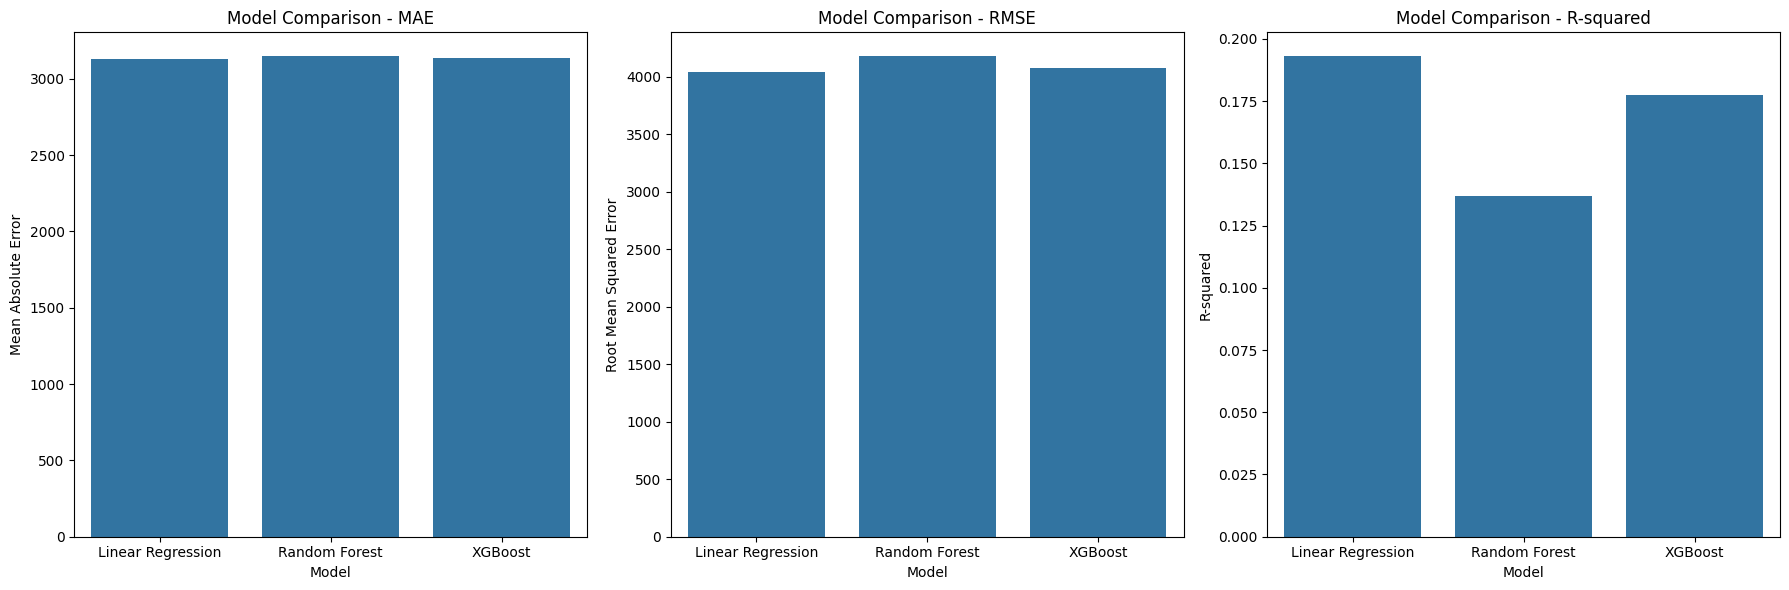

In [29]:
# Visualize the performance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(x='Model', y='MAE', data=performance_summary, ax=axes[0])
axes[0].set_title('Model Comparison - MAE')
axes[0].set_ylabel('Mean Absolute Error')

sns.barplot(x='Model', y='RMSE', data=performance_summary, ax=axes[1])
axes[1].set_title('Model Comparison - RMSE')
axes[1].set_ylabel('Root Mean Squared Error')

sns.barplot(x='Model', y='R-squared', data=performance_summary, ax=axes[2])
axes[2].set_title('Model Comparison - R-squared')
axes[2].set_ylabel('R-squared')

plt.tight_layout()
plt.show()

In [30]:
import joblib

# Define file paths for saving the models
linear_reg_model_path = 'linear_regression_model.joblib'
rf_reg_model_path = 'random_forest_model.joblib'
xgb_reg_model_path = 'xgboost_model.joblib'

# Save the models
joblib.dump(linear_reg_model, linear_reg_model_path)
joblib.dump(rf_reg_model, rf_reg_model_path)
joblib.dump(xgb_reg_model, xgb_reg_model_path)

print(f"Linear Regression model saved to: {linear_reg_model_path}")
print(f"Random Forest model saved to: {rf_reg_model_path}")
print(f"XGBoost model saved to: {xgb_reg_model_path}")

Linear Regression model saved to: linear_regression_model.joblib
Random Forest model saved to: random_forest_model.joblib
XGBoost model saved to: xgboost_model.joblib


**Summary of Model Performance:**

Based on the evaluation metrics:

*   **Linear Regression:** Achieved an R-squared of 0.19, an MAE of 3130.80, and an RMSE of 4038.84.
*   **Random Forest:** Achieved an R-squared of 0.14, an MAE of 3147.63, and an RMSE of 4176.41.
*   **XGBoost:** Achieved an R-squared of 0.18, an MAE of 3139.86, and an RMSE of 4077.75.

All models showed relatively low R-squared values, indicating that the selected features explain a limited portion of the variance in the clipped ticket price. The MAE and RMSE values suggest that the models' predictions have an average error of around 3100-3200 units in the clipped ticket price. Linear Regression performed slightly better in terms of R-squared and RMSE compared to Random Forest and XGBoost on this dataset with the chosen hyperparameters.

In [31]:
df['price_per_quantity'] = df['Ticket_Price_clipped'] / df['Quantity']
df['days_to_match_squared'] = df['Days_Before_Match'] ** 2
df['demand_weekend_interaction'] = df['Demand_Level_Code'] * df['Is_Weekend']
df['team_A_vs_B'] = df['Team_A_Code'].astype(str) + '_' + df['Team_B_Code'].astype(str)
df['stadium_city'] = df['Stadium_Code'].astype(str) + '_' + df['City_Code'].astype(str)

display(df[['price_per_quantity', 'days_to_match_squared', 'demand_weekend_interaction', 'team_A_vs_B', 'stadium_city']].head())

,price_per_quantity,days_to_match_squared,demand_weekend_interaction,team_A_vs_B,stadium_city
0,3000.000000,22500,0,64_70,8_8
1,3686.333333,225,0,17_13,10_10
2,2983.750000,16900,2,28_30,10_10
3,7500.000000,1936,0,79_80,2_2
4,9060.000000,225,3,74_78,9_9


## Hyperparameter tuning

### Subtask:
Tune the hyperparameters of the Random Forest and XGBoost models using techniques like GridSearchCV or RandomizedSearchCV.


**Reasoning**:
Import the necessary library for hyperparameter tuning and define the parameter grids for Random Forest and XGBoost models.



In [32]:
from sklearn.model_selection import GridSearchCV

# Define parameter grids for hyperparameter tuning
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

**Reasoning**:
Instantiate the models and GridSearchCV objects, then fit the GridSearchCV objects to the training data.



In [ ]:
# Instantiate Random Forest and XGBoost models
rf_reg_model = RandomForestRegressor(random_state=42, n_jobs=-1)
xgb_reg_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

# Instantiate GridSearchCV for each model
grid_search_rf = GridSearchCV(estimator=rf_reg_model, param_grid=param_grid_rf,
                              scoring='r2', cv=3, n_jobs=-1, verbose=2)

grid_search_xgb = GridSearchCV(estimator=xgb_reg_model, param_grid=param_grid_xgb,
                               scoring='r2', cv=3, n_jobs=-1, verbose=2)

# Fit the GridSearchCV objects to the training data
print("Tuning Random Forest Regressor...")
grid_search_rf.fit(X_train, y_train)

print("\nTuning XGBoost Regressor...")
grid_search_xgb.fit(X_train, y_train)

# Store the best estimators
best_rf_model = grid_search_rf.best_estimator_
best_xgb_model = grid_search_xgb.best_estimator_

print("\nBest parameters for Random Forest:", grid_search_rf.best_params_)
print("Best R-squared for Random Forest:", grid_search_rf.best_score_)

print("\nBest parameters for XGBoost:", grid_search_xgb.best_params_)
print("Best R-squared for XGBoost:", grid_search_xgb.best_score_)

Tuning Random Forest Regressor...
Fitting 3 folds for each of 108 candidates, totalling 324 fits


## Model evaluation

### Subtask:
Re-evaluate the models with the new features and tuned hyperparameters using MAE, RMSE, and R-squared.


**Reasoning**:
Evaluate the tuned Random Forest and XGBoost models on the test set and print their performance metrics.



In [ ]:
# Make predictions on the test set using the best models
y_pred_rf_tuned = best_rf_model.predict(X_test)
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

# Evaluate the tuned Random Forest model
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Regressor Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_rf_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_tuned:.2f}")
print(f"R-squared (R²): {r2_rf_tuned:.2f}")

# Evaluate the tuned XGBoost model
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print("\nTuned XGBoost Regressor Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_xgb_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb_tuned:.2f}")
print(f"R-squared (R²): {r2_xgb_tuned:.2f}")

**Reasoning**:
The previous command failed because the `best_rf_model` and `best_xgb_model` variables were not defined in the current session. Need to re-run the hyperparameter tuning code to define these variables.



In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grids for hyperparameter tuning
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Instantiate Random Forest and XGBoost models
rf_reg_model = RandomForestRegressor(random_state=42, n_jobs=-1)
xgb_reg_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

# Instantiate GridSearchCV for each model
grid_search_rf = GridSearchCV(estimator=rf_reg_model, param_grid=param_grid_rf,
                              scoring='r2', cv=3, n_jobs=-1, verbose=2)

grid_search_xgb = GridSearchCV(estimator=xgb_reg_model, param_grid=param_grid_xgb,
                               scoring='r2', cv=3, n_jobs=-1, verbose=2)

# Fit the GridSearchCV objects to the training data
print("Tuning Random Forest Regressor...")
grid_search_rf.fit(X_train, y_train)

print("\nTuning XGBoost Regressor...")
grid_search_xgb.fit(X_train, y_train)

# Store the best estimators
best_rf_model = grid_search_rf.best_estimator_
best_xgb_model = grid_search_xgb.best_estimator_

print("\nBest parameters for Random Forest:", grid_search_rf.best_params_)
print("Best R-squared for Random Forest:", grid_search_rf.best_score_)

print("\nBest parameters for XGBoost:", grid_search_xgb.best_params_)
print("Best R-squared for XGBoost:", grid_search_xgb.best_score_)

**Reasoning**:
Now that the `best_rf_model` and `best_xgb_model` are defined, evaluate their performance on the test set using MAE, RMSE, and R-squared as requested in the subtask instructions.



In [ ]:
# Make predictions on the test set using the best models
y_pred_rf_tuned = best_rf_model.predict(X_test)
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

# Evaluate the tuned Random Forest model
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Regressor Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_rf_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_tuned:.2f}")
print(f"R-squared (R²): {r2_rf_tuned:.2f}")

# Evaluate the tuned XGBoost model
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print("\nTuned XGBoost Regressor Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_xgb_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb_tuned:.2f}")
print(f"R-squared (R²): {r2_xgb_tuned:.2f}")

## Performance comparison

### Subtask:
Compare the performance of the models with and without the new features and tuned hyperparameters.


**Reasoning**:
Create a DataFrame to summarize the performance metrics for all four models and display it.



In [ ]:
performance_summary_all = pd.DataFrame({
    'Model': ['Linear Regression (Initial)', 'Random Forest (Initial)', 'XGBoost (Initial)', 'Random Forest (Tuned)', 'XGBoost (Tuned)'],
    'MAE': [mae_lr, mae_rf, mae_xgb, mae_rf_tuned, mae_xgb_tuned],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb, rmse_rf_tuned, rmse_xgb_tuned],
    'R-squared': [r2_lr, r2_rf, r2_xgb, r2_rf_tuned, r2_xgb_tuned]
})

print("Overall Model Performance Summary:")
display(performance_summary_all)